# Importando bibliotecas necessárias


In [35]:
import pandas as pd #biblioteca pandas
import numpy as np #biblioteca numpy
import plotly.express as px # para fazer gráficos
from sklearn.compose import make_column_transformer #para transformar colunas de dados em outros formatos
from sklearn.preprocessing import OneHotEncoder # para converter colunas não numéricas
from imblearn.over_sampling import SMOTE # para balancear dados de evasão
from sklearn.preprocessing import StandardScaler # para padronizar e normalizar dados
import matplotlib.pyplot as plt # biblioteca para gráficos
import seaborn as sns #biblioteca para gráficos

from sklearn.model_selection import train_test_split# para separar dados de treino e treino
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Extração do arquivo tratado

In [5]:
## carregando arquivo TelecomX_Dados_Tratados.csv

df = pd.read_csv('TelecomX_Dados_Tratados.csv')

df

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0,feminino,0,1,1,9,1,0,dsl,0,1,0,1,1,0,anual,1,cheque por correio,65.60,593.30
1,0,masculino,0,0,0,9,1,1,dsl,0,0,0,0,0,1,mensal,0,cheque por correio,59.90,542.40
2,1,masculino,0,0,0,4,1,0,fibra ótica,0,0,1,0,0,0,mensal,1,cheque eletrônico,73.90,280.85
3,1,masculino,1,1,0,13,1,0,fibra ótica,0,1,1,0,1,1,mensal,1,cheque eletrônico,98.00,1237.85
4,1,feminino,1,1,0,3,1,0,fibra ótica,0,0,0,1,1,0,mensal,1,cheque por correio,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,feminino,0,0,0,13,1,0,dsl,1,0,0,1,0,0,anual,0,cheque por correio,55.15,742.90
7039,1,masculino,0,1,0,22,1,1,fibra ótica,0,0,0,0,0,1,mensal,1,cheque eletrônico,85.10,1873.70
7040,0,masculino,0,0,0,2,1,0,dsl,0,1,0,0,0,0,mensal,1,cheque por correio,50.30,92.75
7041,0,masculino,0,1,1,67,1,0,dsl,1,0,1,1,0,1,dois anos,0,cheque por correio,67.85,4627.65


# Encoding

In [10]:
colunas = df.columns
colunas

Index(['churn', 'customer_seniorcitizen', 'customer_partner',
       'customer_dependents', 'customer_tenure', 'phone_phoneservice',
       'phone_multiplelines', 'internet_onlinesecurity',
       'internet_onlinebackup', 'internet_deviceprotection',
       'internet_techsupport', 'internet_streamingtv',
       'internet_streamingmovies', 'account_paperlessbilling',
       'account_charges_monthly', 'account_charges_total',
       'customer_gender_masculino', 'internet_internetservice_dsl',
       'internet_internetservice_fibra ótica', 'account_contract_dois anos',
       'account_contract_mensal', 'account_paymentmethod_cheque eletrônico',
       'account_paymentmethod_cheque por correio',
       'account_paymentmethod_transferência bancária (automática)'],
      dtype='object')

In [14]:
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"Colunas que serão codificadas: {colunas_categoricas}\n")

colunas = df.columns
colunas


# OneHotEncoder
# drop='first' evita a armadilha da variável dummy (multicolinearidade)
# sparse_output=False garante que o resultado seja um array normal, fácil de unir ao Pandas
encoder = OneHotEncoder(drop='first', sparse_output= False)

# 3. Ajustar (fit) e transformar (transform) os dados categóricos
dados_codificados = encoder.fit_transform(df[colunas_categoricas])

# 4. Resgatar os nomes exatos das novas colunas geradas pelo encoder
nomes_novas_colunas = encoder.get_feature_names_out(colunas_categoricas)

# 5. Transformar o array gerado de volta em um DataFrame do Pandas
df_codificado = pd.DataFrame(dados_codificados, columns=nomes_novas_colunas, index=df.index)

# 6. Unir (concatenar) o novo DataFrame codificado ao original e remover as colunas de texto antigas
df = pd.concat([df.drop(columns=colunas_categoricas), df_codificado], axis=1)

df.head()

Colunas que serão codificadas: []



,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,...,account_charges_monthly,account_charges_total,customer_gender_masculino,internet_internetservice_dsl,internet_internetservice_fibra ótica,account_contract_dois anos,account_contract_mensal,account_paymentmethod_cheque eletrônico,account_paymentmethod_cheque por correio,account_paymentmethod_transferência bancária (automática)
0,0,0,1,1,9,1,0,0,1,0,...,65.6,593.30,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,0,0,9,1,1,0,0,0,...,59.9,542.40,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1,0,0,0,4,1,0,0,0,1,...,73.9,280.85,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,1,1,1,0,13,1,0,0,1,1,...,98.0,1237.85,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1,1,1,0,3,1,0,0,0,0,...,83.9,267.40,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


# Verificar taxa de evasão dos clientes

In [16]:
# 1. Calcular a contagem absoluta de cada classe
contagem_absoluta = df['churn'].value_counts()
print("Contagem absoluta de clientes:")
print(contagem_absoluta)

# 2. Calcular a proporção (porcentagem) de cada classe
proporcao = df['churn'].value_counts(normalize=True) * 100
print("\nProporção das classes (%):")
print(proporcao.round(2)) # round(2) para deixar com duas casas decimais

Contagem absoluta de clientes:
churn
0    5174
1    1869
Name: count, dtype: int64

Proporção das classes (%):
churn
0    73.46
1    26.54
Name: proportion, dtype: float64


# Balanceando dados utilizando SMOTE

In [18]:
# 1. Separar as variáveis explicativas (X) da variável alvo (y)
X = df.drop(columns=['churn'])
y = df['churn']

# 2. Instanciar o algoritmo SMOTE
# O random_state=42 garante que o resultado será o mesmo toda vez que você rodar
smote = SMOTE(random_state=42)

# 3. Aplicar o balanceamento aos dados
X_balanceado, y_balanceado = smote.fit_resample(X, y)

# 4. Verificar o resultado antes e depois
print("Contagem de classes ANTES do SMOTE:")
print(y.value_counts())

print("\nContagem de classes APÓS o SMOTE:")
print(y_balanceado.value_counts())

Contagem de classes ANTES do SMOTE:
churn
0    5174
1    1869
Name: count, dtype: int64

Contagem de classes APÓS o SMOTE:
churn
0    5174
1    5174
Name: count, dtype: int64


# Normalização e Padronização

In [21]:


# 1. Definir quais são as colunas numéricas contínuas
colunas_continuas = ['customer_tenure', 'account_charges_monthly', 'account_charges_total']

# 2. Fazer uma cópia do X_balanceado para manter os dados organizados
X_padronizado = X_balanceado.copy()

# 3. Instanciar o padronizador
scaler = StandardScaler()

# 4. Ajustar e transformar apenas as colunas contínuas
X_padronizado[colunas_continuas] = scaler.fit_transform(X_padronizado[colunas_continuas])

# 5. Visualizar como ficaram os dados após a transformação
print("Dados numéricos após a padronização (média ~ 0, desvio padrão ~ 1):")
display(X_padronizado[colunas_continuas].head())

Dados numéricos após a padronização (média ~ 0, desvio padrão ~ 1):


,customer_tenure,account_charges_monthly,account_charges_total
0,-0.777744,-0.084753,-0.664636
1,-0.777744,-0.283258,-0.687910
2,-0.986192,0.204298,-0.807506
3,-0.610986,1.043591,-0.369911
4,-1.027882,0.552552,-0.813656


# Análise de correlação

C:\Users\Otavio\AppData\Local\Temp\ipykernel_1476\2870877392.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




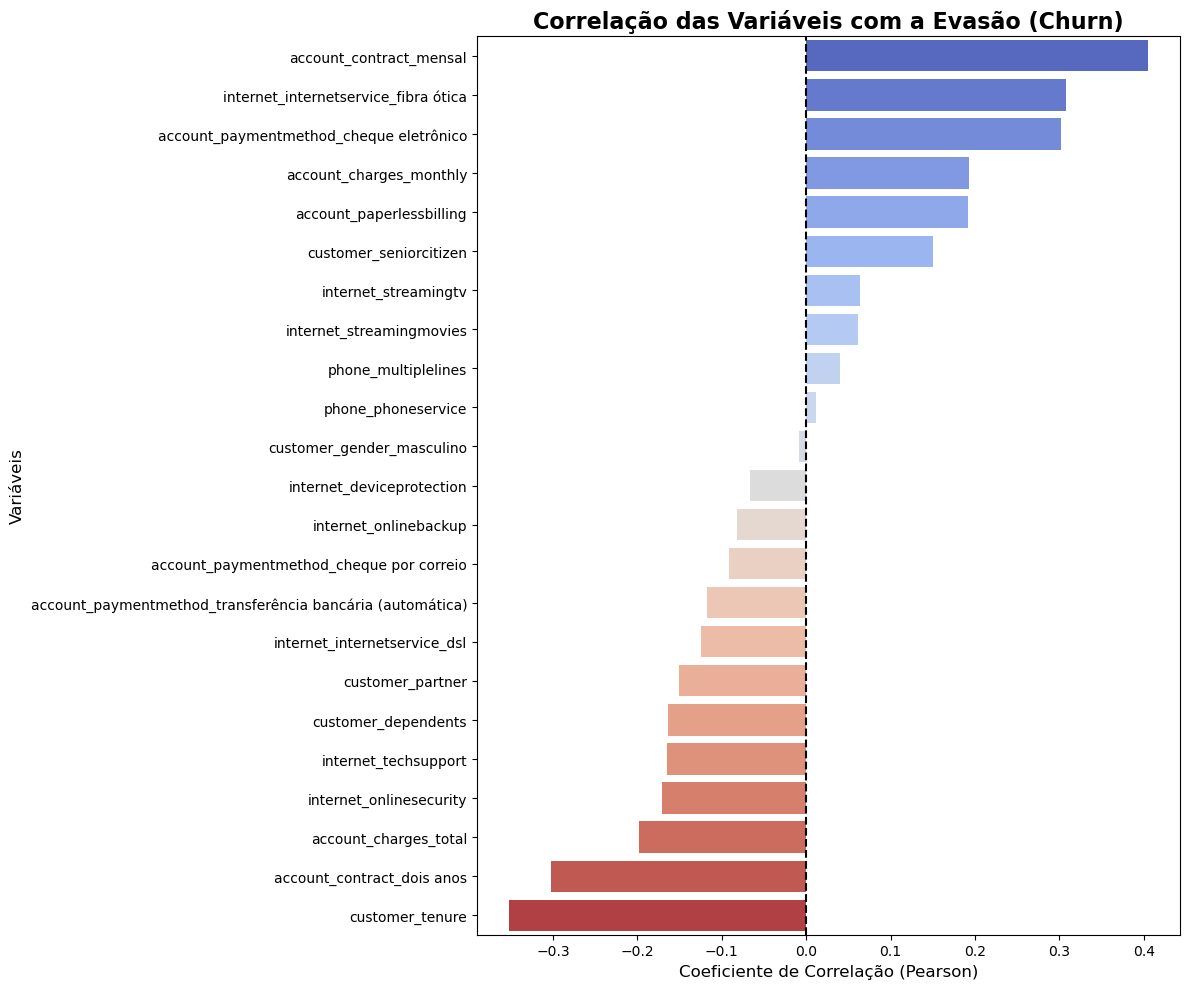

🔴 Top 5 fatores que MAIS AUMENTAM o risco de Churn (Correlação Positiva):
account_contract_mensal                    0.405103
internet_internetservice_fibra ótica       0.308020
account_paymentmethod_cheque eletrônico    0.301919
account_charges_monthly                    0.193356
account_paperlessbilling                   0.191825
Name: churn, dtype: float64

🟢 Top 5 fatores que MAIS DIMINUEM o risco de Churn (Correlação Negativa):
internet_techsupport         -0.164674
internet_onlinesecurity      -0.171226
account_charges_total        -0.198324
account_contract_dois anos   -0.302253
customer_tenure              -0.352229
Name: churn, dtype: float64


In [25]:
# 1. Calcular a matriz de correlação completa do DataFrame
correlacoes = df.corr()

# 2. Isolar a correlação de todas as variáveis apenas com o 'churn' e ordenar
correlacao_churn = correlacoes['churn'].sort_values(ascending=False)

# Remover o próprio 'churn' da visualização (pois a correlação dele com ele mesmo é 1.0)
correlacao_churn = correlacao_churn.drop('churn')

# 3. Configurar o visual do gráfico de barras
plt.figure(figsize=(12, 10))
sns.barplot(x=correlacao_churn.values, y=correlacao_churn.index, palette='coolwarm')

# 4. Ajustes estéticos
plt.title('Correlação das Variáveis com a Evasão (Churn)', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlação (Pearson)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Linha central no zero
plt.tight_layout()
plt.show()

# 5. Exibir os extremos em formato de texto para o relatório
print("🔴 Top 5 fatores que MAIS AUMENTAM o risco de Churn (Correlação Positiva):")
print(correlacao_churn.head(5))

print("\n🟢 Top 5 fatores que MAIS DIMINUEM o risco de Churn (Correlação Negativa):")
print(correlacao_churn.tail(5))

# Análises Direcionadas

C:\Users\Otavio\AppData\Local\Temp\ipykernel_1476\3232114459.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Otavio\AppData\Local\Temp\ipykernel_1476\3232114459.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




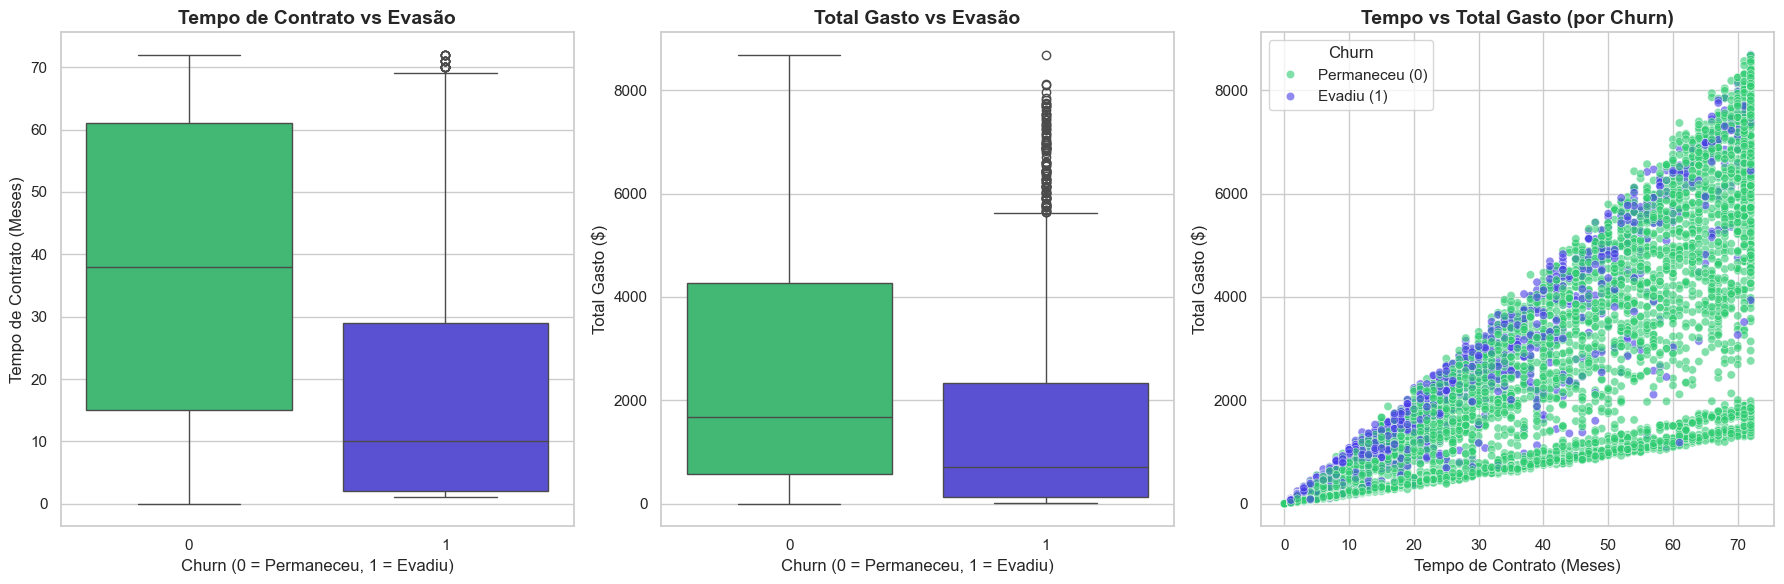

In [29]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot: Tempo de Contrato x Evasão
sns.boxplot(data=df, x='churn', y='customer_tenure', ax=axes[0], palette=['#2ecc71', '#473ce7'])
axes[0].set_title('Tempo de Contrato vs Evasão', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0 = Permaneceu, 1 = Evadiu)', fontsize=12)
axes[0].set_ylabel('Tempo de Contrato (Meses)', fontsize=12)

# 2. Boxplot: Total Gasto x Evasão
sns.boxplot(data=df, x='churn', y='account_charges_total', ax=axes[1], palette=['#2ecc71', "#473ce7"])
axes[1].set_title('Total Gasto vs Evasão', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn (0 = Permaneceu, 1 = Evadiu)', fontsize=12)
axes[1].set_ylabel('Total Gasto ($)', fontsize=12)

# 3. Scatter Plot: Tempo de Contrato vs Total Gasto (Colorido por Evasão)
sns.scatterplot(data=df, x='customer_tenure', y='account_charges_total', hue='churn', 
                alpha=0.6, palette=['#2ecc71', '#473ce7'], ax=axes[2])
axes[2].set_title('Tempo vs Total Gasto (por Churn)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tempo de Contrato (Meses)', fontsize=12)
axes[2].set_ylabel('Total Gasto ($)', fontsize=12)

handles, previous_labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles=handles, title='Churn', labels=['Permaneceu (0)', 'Evadiu (1)'])


# Ajustar o layout e exibir
plt.tight_layout()
plt.show()

# Separação de Dados

In [ ]:
# 1. Realizar a divisão dos dados (80% Treino / 20% Teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_padronizado, 
    y_balanceado, 
    test_size=0.20, #separar (treino/teste) = 80/20
    random_state=42, #para garantir repordutibilidade
    stratify=y_balanceado
)

# 2. Conferir o tamanho dos conjuntos gerados
print("📊 Resumo da Divisão de Dados:")
print(f"Tamanho do X_treino: {X_treino.shape}")
print(f"Tamanho do y_treino: {y_treino.shape}")
print("-" * 30)
print(f"Tamanho do X_teste: {X_teste.shape}")
print(f"Tamanho do y_teste: {y_teste.shape}")

📊 Resumo da Divisão de Dados:
Tamanho do X_treino: (8278, 23)
Tamanho do y_treino: (8278,)
------------------------------
Tamanho do X_teste: (2070, 23)
Tamanho do y_teste: (2070,)


# Criação de Modelos

In [34]:
# 1. Instanciar os modelos
# max_iter=1000 na Regressão Logística evita avisos de limite de iterações
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

# n_estimators=100 significa que o Random Forest criará 100 árvores de decisão
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Treinar (fit) os modelos com os dados de treino
print("Treinando o modelo de Regressão Logística...")
modelo_logistico.fit(X_treino, y_treino)

print("Treinando o modelo de Random Forest...")
modelo_rf.fit(X_treino, y_treino)

# 3. Realizar as previsões (predict) usando os dados de teste (que o modelo não conhece)
previsoes_logistico = modelo_logistico.predict(X_teste)
previsoes_rf = modelo_rf.predict(X_teste)

print("\nModelos treinados e previsões realizadas com sucesso! ✅")

Treinando o modelo de Regressão Logística...
Treinando o modelo de Random Forest...

Modelos treinados e previsões realizadas com sucesso! ✅


# Avaliação dos modelos

--- avaliação: regressão logística ---
acurácia: 0.8188
precisão: 0.8137
recall: 0.8271
f1-score: 0.8203

relatório de classificação:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.81      0.83      0.82      1035

    accuracy                           0.82      2070
   macro avg       0.82      0.82      0.82      2070
weighted avg       0.82      0.82      0.82      2070



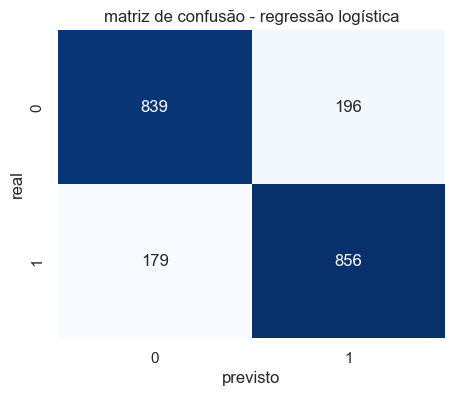

--- avaliação: random forest ---
acurácia: 0.8580
precisão: 0.8643
recall: 0.8493
f1-score: 0.8567

relatório de classificação:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.86      0.85      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



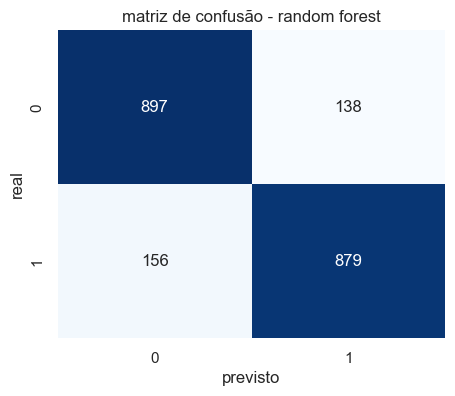

In [41]:
# função para avaliar os modelos
def avaliar_modelo(nome_modelo, y_verdadeiro, y_previsto):
    print(f"--- avaliação: {nome_modelo} ---")
    print(f"acurácia: {accuracy_score(y_verdadeiro, y_previsto):.4f}")
    print(f"precisão: {precision_score(y_verdadeiro, y_previsto):.4f}")
    print(f"recall: {recall_score(y_verdadeiro, y_previsto):.4f}")
    print(f"f1-score: {f1_score(y_verdadeiro, y_previsto):.4f}\n")
    
    print("relatório de classificação:")
    print(classification_report(y_verdadeiro, y_previsto))
    
    # plotando a matriz de confusão
    cm = confusion_matrix(y_verdadeiro, y_previsto)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap ='Blues',  cbar=False)
    plt.title(f'matriz de confusão - {nome_modelo}')
    plt.xlabel('previsto')
    plt.ylabel('real')
    plt.show()

# avaliando a regressão logística
avaliar_modelo("regressão logística", y_teste, previsoes_logistico)

# avaliando o random forest
avaliar_modelo("random forest", y_teste, previsoes_rf)

# Analise da importancia das variáveis

C:\Users\Otavio\AppData\Local\Temp\ipykernel_1476\3733827558.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Otavio\AppData\Local\Temp\ipykernel_1476\3733827558.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




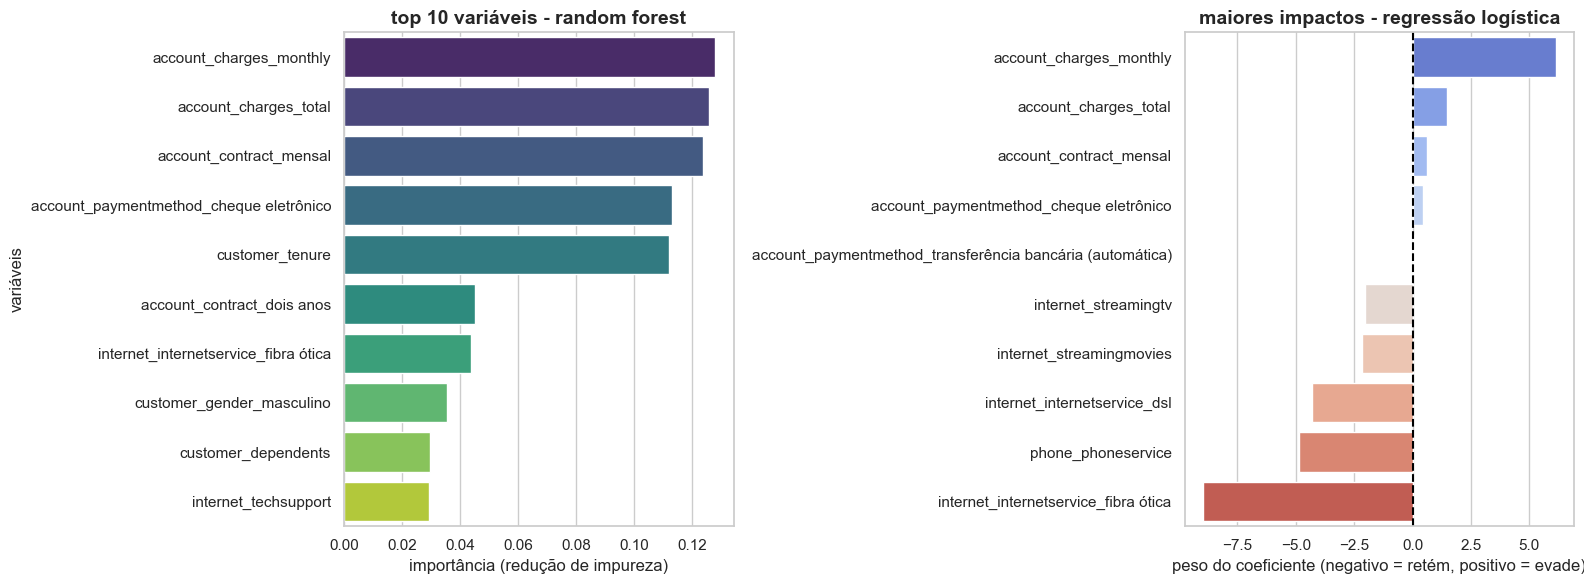

In [42]:
# 1. recuperar os nomes das colunas usadas no treinamento
features = X_treino.columns

# 2. extrair importância do random forest
importancia_rf = pd.DataFrame({
    'variavel': features,
    'importancia': modelo_rf.feature_importances_
}).sort_values(by='importancia', ascending=False)

# 3. extrair coeficientes da regressão logística
importancia_log = pd.DataFrame({
    'variavel': features,
    'coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='coeficiente', ascending=False)

# 4. configurar a visualização lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# gráfico 1: random forest (top 10 variáveis)
sns.barplot(data=importancia_rf.head(10), x='importancia', y='variavel', ax=axes[0], palette='viridis')
axes[0].set_title('top 10 variáveis - random forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('importância (redução de impureza)')
axes[0].set_ylabel('variáveis')

# gráfico 2: regressão logística (juntando os 5 maiores e 5 menores coeficientes)
top_positivos = importancia_log.head(5)
top_negativos = importancia_log.tail(5)
top_log = pd.concat([top_positivos, top_negativos]).sort_values(by='coeficiente', ascending=False)

sns.barplot(data=top_log, x='coeficiente', y='variavel', ax=axes[1], palette='coolwarm')
axes[1].set_title('maiores impactos - regressão logística', fontsize=14, fontweight='bold')
axes[1].set_xlabel('peso do coeficiente (negativo = retém, positivo = evade)')
axes[1].set_ylabel('')
axes[1].axvline(x=0, color='black', linestyle='--')

# ajustar layout e mostrar
plt.tight_layout()
plt.show()

# Relatório final

## Resumo dos métodos e preparação de dados

Inicialmente, tratamos os dados eliminando a coluna com o ID do cliente, evitando problemas de overfitting. Em seguida, transformamos as variáveis categóricas em numéricas utilizando o método de one-hot encoding, permitindo que os modelos pudessem interpretar e usar essas informações em suas predições.

Em uma análise prévia dos dados, observamos cerca de 73% de permanência contra 27% de evasão. Por conta desse desbalanceamento, foi necessário aplicar o método SMOTE nos dados de treino para não enviesar o aprendizado de máquina.

As variáveis de tempo e financeiras também foram padronizadas — utilizando o método StandardScaler — para evitar que a regressão logística atribuísse muito peso a números absolutos maiores. Por fim, dividimos os dados em 80% para treino e 20% para teste, mantendo a proporção original das classes (estratificação).
## Análises e resultados

A partir das análises feitas com os dois modelos escolhidos (Regressão Logística e Random Forest), observamos que as variáveis customer_tenure, account_charges_monthly e account_charges_total são as que mais impactam na decisão de cancelamento dos clientes, segundo o modelo de árvore de decisão.

Já na nossa análise de regressão logística, o contrato mensal e o pagamento via cheque eletrônico despontam como os maiores causadores de evasão. Por outro lado, o fato de um cliente ter vários serviços ativos contratados funciona como uma forte âncora para garantir sua permanência na empresa.

Além disso, nossos modelos provaram que a maior taxa de evasão entre os clientes de fibra ótica não está ligada à tecnologia em si, mas sim ao alto valor da mensalidade cobrada em contratos sem fidelidade.
## Propostas para permanência de clientes

Como propostas para a retenção de clientes, sugerimos a criação de campanhas que promovam bônus para incentivar a migração de planos mensais para anuais (de um ou dois anos).

Também recomendamos estimular a troca da forma de pagamento manual (via cheque eletrônico) para débito automático ou cartão de crédito. Para tal, benefícios e descontos podem ser fornecidos em contrapartida.

A criação de combos de serviços — como fibra ótica atrelada a assinaturas de streaming, entre outros — é uma excelente solução estratégica para diminuir o cancelamento. Além disso, é necessário ter uma atenção redobrada aos clientes recém-adquiridos por meio de um bom programa de boas-vindas (onboarding), pois é nesse período inicial que reside o maior risco de evasão.